# Synchonization analysis: Hilbert + Kuramoto + Joint Recurrence Plots (T11/T12 Temperatures)

**Objective:** Identify the optimal time lag between T11 and T12 using:

1. **Hilbert Transform + Kuramoto Order Parameter** (phase synchronization)
2. **Joint Recurrence Plots (JRP)** (state synchronization in phase space)

The T11 and T12 signals already exhibit a natural (physical) time delay between them.

---

**Optimal Lag Criterion (Kuramoto):** Fraction of time with strong phase synchronization (`frac_above_07`) × Mean r (`r_mean`)

The Kuramoto score combines the normalized `frac_above_07` (fraction of time with r > 0.7) and `r_mean` (mean order parameter).

**Optimal Lag Criterion (JRP):** Determinism (DET) × Laminarity (LAM) × Recurrence Rate (RR)

**Combined Score:** Arithmetic mean of both normalized scores.

**Real Lag:** Calculated as distance / velocity.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d
from scipy.spatial.distance import pdist, squareform

# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_parquet('../data/datos_ind.pqt')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Columns: {df.columns.tolist()}')

Shape: (24383269, 10)
Date range: 2021-01-03 01:35:46.772000 to 2021-12-23 00:00:00.287000
Columns: ['FormacionNIRHumedadPV', 'BasculaMantaPesoPV', 'SierrasAnchoPV', 'FormacionMantaCentroAltura', 'FormacionAlturaMantaPV', 'FormacionVelocidadSP', 'FormacionVelocidad', 'FormacionMWEntT11TempPV', 'MWPotenciaPV', 'FormacionMWSalT12TempPV']


In [2]:
# Select temporal window
start_time = '2021-11-03 12:10:00'
end_time = '2021-11-03 12:30:00'

df_hour = df.loc[start_time:end_time].copy()
print(f'Window: {df_hour.index[0]} to {df_hour.index[-1]}')
print(f'Length: {len(df_hour)} samples')

# Extract signals: T12 (salida) as reference, T11 (entrada) as delayed
s1 = pd.Series(df_hour['FormacionMWSalT12TempPV'].values).interpolate().values
s2 = pd.Series(df_hour['FormacionMWEntT11TempPV'].values).interpolate().values

# Extract velocity
vel = df_hour['FormacionVelocidad'].values

# Normalize to [-1, 1] centered at 0
def normalize_zero_centered(x):
    x = np.asarray(x, dtype=float)
    x_centered = x - np.mean(x)
    max_abs = np.max(np.abs(x_centered))
    if max_abs > 0:
        return x_centered / max_abs
    return x_centered

s1_norm = normalize_zero_centered(s1)
s2_norm = normalize_zero_centered(s2)
vel_norm = normalize_zero_centered(vel)

# Apply smoothing (moving average) to reduce noise
def smooth_signal(x, window=5):
    """Apply moving average smoothing."""
    return uniform_filter1d(x, size=window, mode='reflect')

# Smoothing window for Kuramoto analysis (lighter smoothing)
smooth_window_kuramoto = 10  # 10 seconds at 1 Hz
s1_smooth_kuramoto = smooth_signal(s1_norm, window=smooth_window_kuramoto)
s2_smooth_kuramoto = smooth_signal(s2_norm, window=smooth_window_kuramoto)

# Smoothing window for JRP analysis (heavier smoothing for better results)
smooth_window_jrp = 10  # 10 seconds at 1 Hz
s1_smooth = smooth_signal(s1_norm, window=smooth_window_jrp)
s2_smooth = smooth_signal(s2_norm, window=smooth_window_jrp)

time_axis = np.arange(len(s1_norm))
sampling_rate = 1.0  # 1 Hz

# Real lag calculation (distance/speed)
real_lag = int(18600 / df_hour['FormacionVelocidad'].mean())
print(f'Real lag (distance/speed): {real_lag}s ({real_lag/60:.1f} min)')
print(f'Smoothing window for Kuramoto: {smooth_window_kuramoto}s')
print(f'Smoothing window for JRP: {smooth_window_jrp}s')

Window: 2021-11-03 12:10:00.493000 to 2021-11-03 12:30:00.224000
Length: 1199 samples
Real lag (distance/speed): 90s (1.5 min)
Smoothing window for Kuramoto: 10s
Smoothing window for JRP: 10s


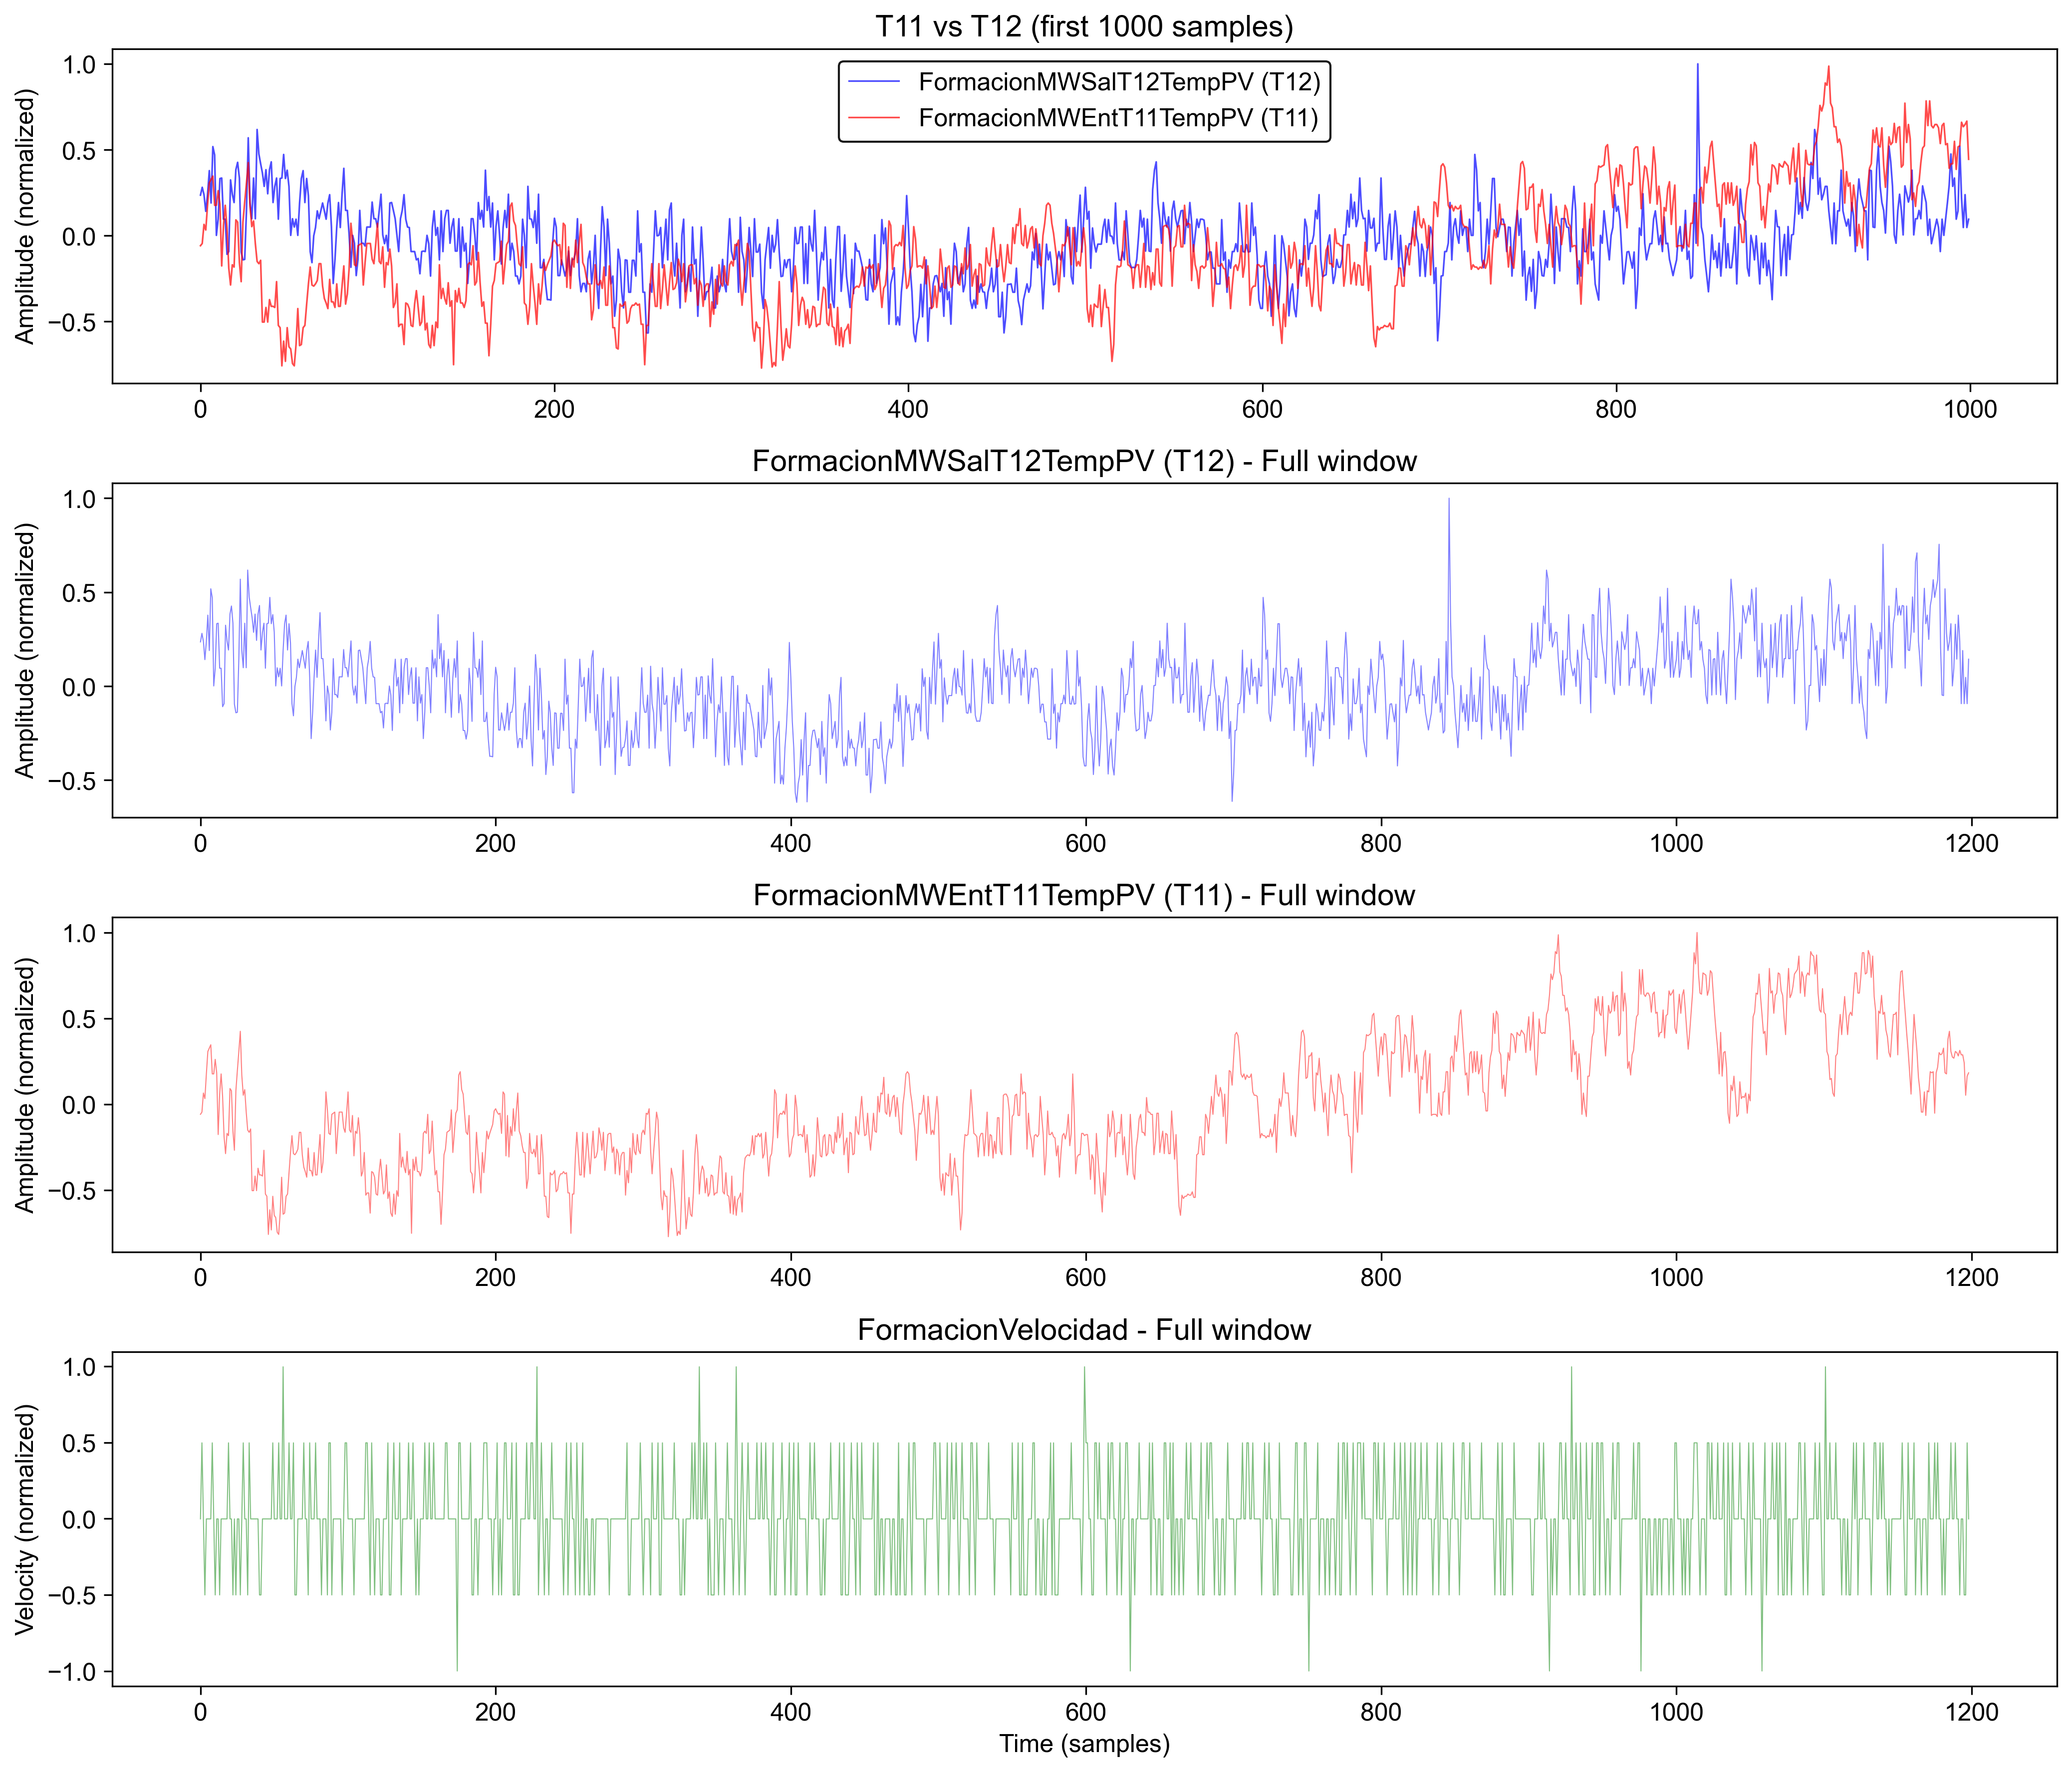

In [3]:
# Plot raw signals with velocity
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.patch.set_facecolor('white')

# First 1000 samples (or all if less)
n_show = min(1000, len(s1_norm))
axes[0].plot(time_axis[:n_show], s1_norm[:n_show], 'b-', label='FormacionMWSalT12TempPV (T12)', alpha=0.7, linewidth=0.8)
axes[0].plot(time_axis[:n_show], s2_norm[:n_show], 'r-', label='FormacionMWEntT11TempPV (T11)', alpha=0.7, linewidth=0.8)
axes[0].set_ylabel('Amplitude (normalized)')
axes[0].set_title(f'T11 vs T12 (first {n_show} samples)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor="black")
axes[0].grid(False)

axes[1].plot(time_axis, s1_norm, 'b-', alpha=0.5, linewidth=0.5)
axes[1].set_ylabel('Amplitude (normalized)')
axes[1].set_title('FormacionMWSalT12TempPV (T12) - Full window')
axes[1].grid(False)

axes[2].plot(time_axis, s2_norm, 'r-', alpha=0.5, linewidth=0.5)
axes[2].set_ylabel('Amplitude (normalized)')
axes[2].set_title('FormacionMWEntT11TempPV (T11) - Full window')
axes[2].grid(False)

axes[3].plot(time_axis, vel_norm, 'g-', alpha=0.5, linewidth=0.5)
axes[3].set_ylabel('Velocity (normalized)')
axes[3].set_xlabel('Time (samples)')
axes[3].set_title('FormacionVelocidad - Full window')
axes[3].grid(False)

plt.tight_layout()
plt.show()

In [4]:
# --- HILBERT + KURAMOTO FUNCTIONS ---
def get_phase(signal):
    analytic = hilbert(signal)
    return np.angle(analytic)

def kuramoto_order_param(phi1, phi2):
    z = 0.5 * (np.exp(1j * phi1) + np.exp(1j * phi2))
    return np.abs(z)

# --- JOINT RECURRENCE PLOT FUNCTIONS ---
def embed_time_series(x, m=3, tau=1):
    """Time-delay embedding."""
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.array([])
    embedded = np.zeros((n - (m - 1) * tau, m))
    for i in range(m):
        embedded[:, i] = x[i * tau:n - (m - 1 - i) * tau]
    return embedded

def recurrence_plot(x, threshold=None, rate=0.05):
    """Compute recurrence plot for a single time series."""
    n = len(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    dists = squareform(pdist(x, metric='euclidean'))
    
    if threshold is None:
        # Fixed recurrence rate threshold
        flat_dists = dists[np.triu_indices(n, k=1)]
        threshold = np.percentile(flat_dists, rate * 100)
    
    rp = dists <= threshold
    return rp, threshold

def joint_recurrence_plot(rp1, rp2):
    """Compute Joint Recurrence Plot: JRP = RP1 AND RP2."""
    return rp1 & rp2

def jrp_rqa_metrics(jrp):
    """Compute RQA metrics from Joint Recurrence Plot."""
    n = jrp.shape[0]
    
    # Recurrence Rate (RR)
    rr = np.sum(jrp) / (n * n)
    
    # Determinism (DET) - fraction of recurrence points forming diagonal lines
    diag_lengths = []
    for offset in range(-n + 1, n):
        diag = np.diag(jrp, k=offset)
        if len(diag) < 2:
            continue
        in_line = False
        length = 0
        for val in diag:
            if val:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    diag_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            diag_lengths.append(length)
    
    if len(diag_lengths) > 0:
        det = np.sum(diag_lengths) / np.sum(jrp)
        max_diag = np.max(diag_lengths)
        mean_diag = np.mean(diag_lengths)
    else:
        det = 0
        max_diag = 0
        mean_diag = 0
    
    # Laminarity (LAM) - vertical lines
    vert_lengths = []
    for col in range(n):
        in_line = False
        length = 0
        for row in range(n):
            if jrp[row, col]:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    vert_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            vert_lengths.append(length)
    
    if len(vert_lengths) > 0:
        lam = np.sum(vert_lengths) / np.sum(jrp)
        max_vert = np.max(vert_lengths)
    else:
        lam = 0
        max_vert = 0
    
    return {
        'RR': rr,
        'DET': det,
        'LAM': lam,
        'max_diag': max_diag,
        'mean_diag': mean_diag,
        'max_vert': max_vert
    }

In [5]:
# --- JRP PARAMETER OPTIMIZATION ---
# Sweep through different rate values to find optimal JRP parameters
print("Optimizing JRP parameters...")
print("=" * 60)

# Test different embedding dimensions and time delays
m_values = [2, 3, 4, 5]
tau_values = [1, 2, 3]
rate_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

best_score = -1
best_params = {}
results_list = []

for m in m_values:
    for tau in tau_values:
        # Embed both signals
        s1_emb_test = embed_time_series(s1_smooth, m=m, tau=tau)
        s2_emb_test = embed_time_series(s2_smooth, m=m, tau=tau)
        
        if len(s1_emb_test) == 0 or len(s2_emb_test) == 0:
            continue
            
        for rate in rate_values:
            # Compute recurrence plots
            rp1_test, _ = recurrence_plot(s1_emb_test, rate=rate)
            rp2_test, _ = recurrence_plot(s2_emb_test, rate=rate)
            jrp_test = joint_recurrence_plot(rp1_test, rp2_test)
            
            # Compute metrics
            metrics_test = jrp_rqa_metrics(jrp_test)
            
            # Combined score (higher DET and RR is better, but not too high LAM)
            score = metrics_test['DET'] + metrics_test['RR']  + metrics_test['LAM']
#            score = metrics_test['DET'] * 0.4 + metrics_test['RR'] * 0.4 + (1 - abs(metrics_test['LAM'] - 0.05)) * 0.2
            results_list.append({
                'm': m,
                'tau': tau,
                'rate': rate,
                'RR': metrics_test['RR'],
                'DET': metrics_test['DET'],
                'LAM': metrics_test['LAM'],
                'max_diag': metrics_test['max_diag'],
                'score': score
            })
            
            if score > best_score:
                best_score = score
                best_params = {'m': m, 'tau': tau, 'rate': rate}

# Convert to DataFrame and display top results
results_df_opt = pd.DataFrame(results_list)
results_df_opt = results_df_opt.sort_values('score', ascending=False)

print("\nTop 10 parameter combinations:")
print(results_df_opt.head(10).to_string(index=False))
print(f"\nBest parameters: m={best_params['m']}, tau={best_params['tau']}, rate={best_params['rate']}")

# Update global parameters with optimal values
m_opt = best_params['m']
tau_opt = best_params['tau']
rate_opt = best_params['rate']
print(f"\nUsing optimized parameters: m={m_opt}, tau={tau_opt}, rate={rate_opt}")

Optimizing JRP parameters...

Top 10 parameter combinations:
 m  tau  rate       RR      DET      LAM  max_diag    score
 5    1   0.3 0.111112 0.990420 0.994908      1195 2.096440
 5    2   0.3 0.113846 0.986724 0.992879      1191 2.093449
 4    1   0.3 0.110622 0.988460 0.993971      1196 2.093054
 5    3   0.3 0.116777 0.983104 0.990251      1187 2.090132
 4    2   0.3 0.112733 0.985117 0.991979      1193 2.089828
 3    1   0.3 0.110267 0.986278 0.993101      1197 2.089645
 3    2   0.3 0.111432 0.984352 0.991114      1195 2.086898
 4    3   0.3 0.115057 0.981808 0.989186      1190 2.086051
 3    3   0.3 0.113015 0.980727 0.988038      1193 2.081781
 2    1   0.3 0.109899 0.981512 0.989273      1198 2.080685

Best parameters: m=5, tau=1, rate=0.3

Using optimized parameters: m=5, tau=1, rate=0.3


Embedded shapes: s1=(1195, 5), s2=(1195, 5)
Thresholds: th1=0.2431, th2=0.4332
JRP Metrics (lag=0): RR=0.1111, DET=0.9904, LAM=0.9949
  max_diag=1195, mean_diag=8.9, max_vert=82


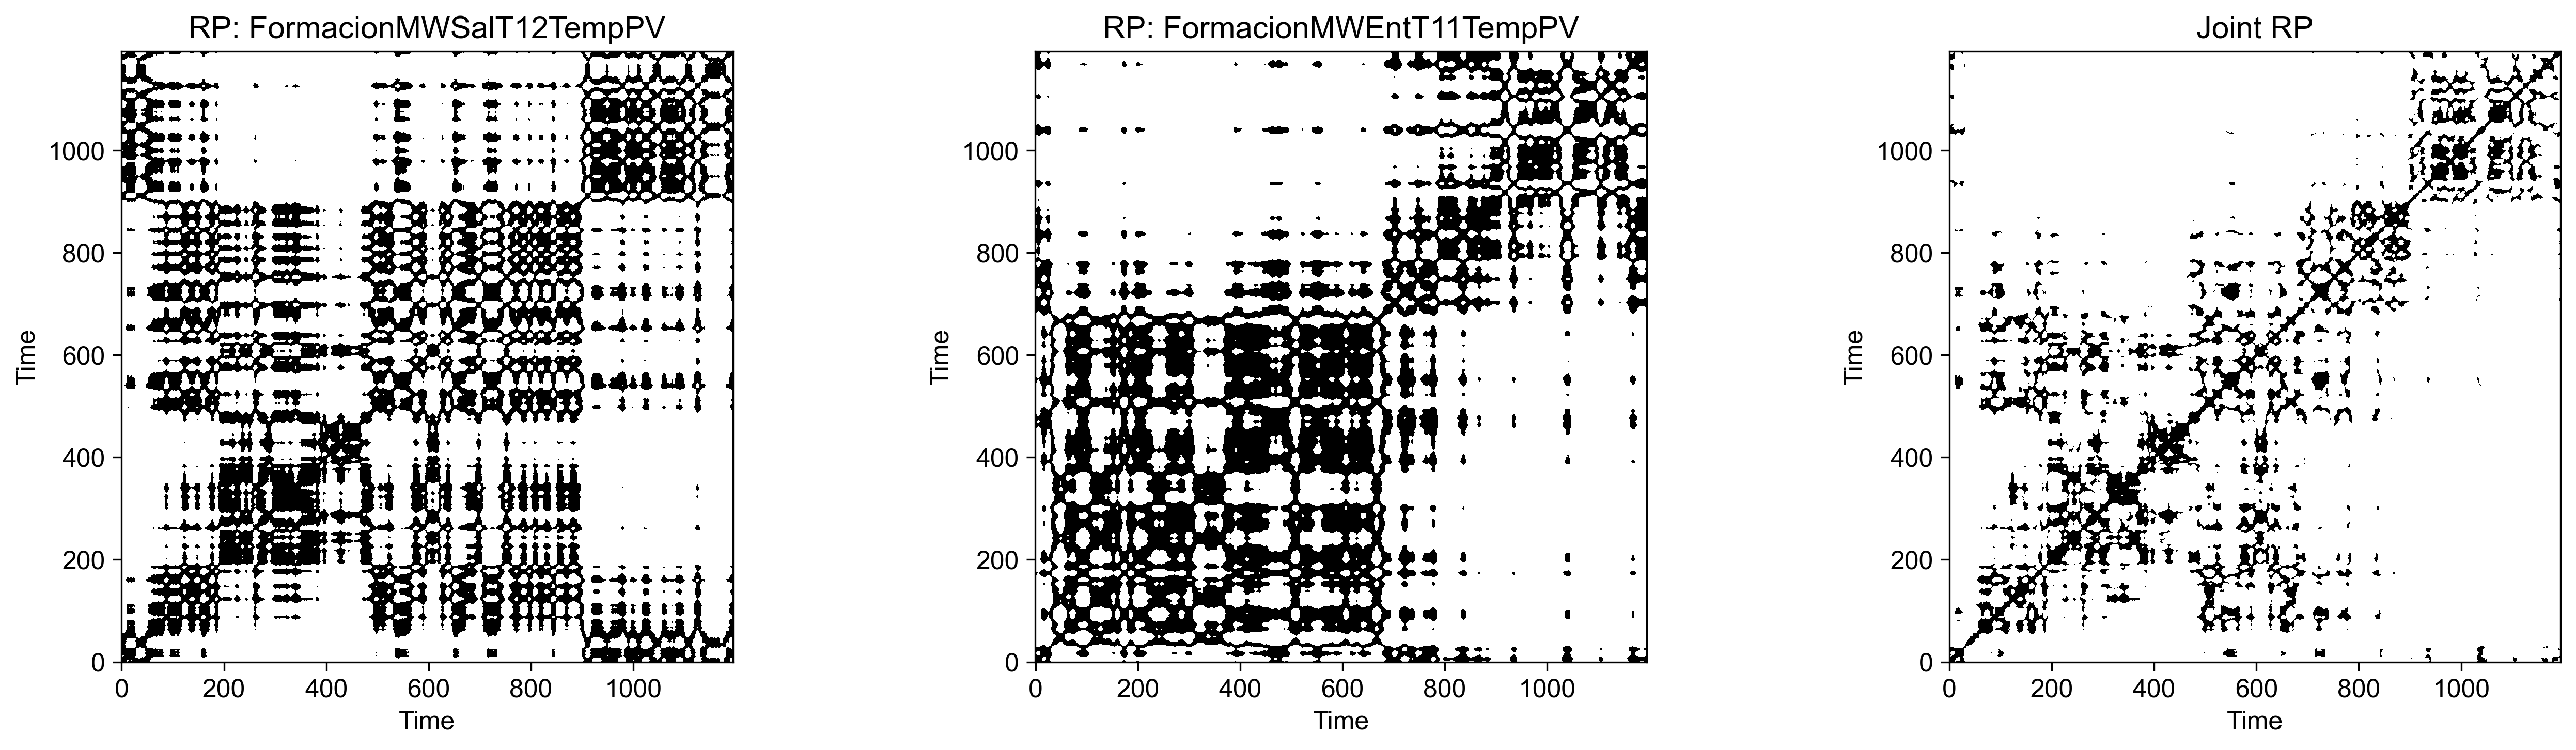

In [6]:
# Test JRP at lag=0 with optimized parameters
m, tau, rate = m_opt, tau_opt, rate_opt
s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)
s2_emb = embed_time_series(s2_smooth, m=m, tau=tau)
s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)
s2_emb = embed_time_series(s2_smooth, m=m, tau=tau)

print(f'Embedded shapes: s1={s1_emb.shape}, s2={s2_emb.shape}')

rp1, thresh1 = recurrence_plot(s1_emb, rate=rate)
rp2, thresh2 = recurrence_plot(s2_emb, rate=rate)
jrp = joint_recurrence_plot(rp1, rp2)

metrics = jrp_rqa_metrics(jrp)
print(f'Thresholds: th1={thresh1:.4f}, th2={thresh2:.4f}')
print(f'JRP Metrics (lag=0): RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')

# Plot RPs and JRP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
for ax, rp, title in zip(axes, [rp1, rp2, jrp], ['RP: FormacionMWSalT12TempPV', 'RP: FormacionMWEntT11TempPV', 'Joint RP']):
    ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('Time')
plt.tight_layout()
plt.show()

In [7]:
# Sweep lags with both Kuramoto and JRP metrics
max_lag = 400
lag_step = 1
lags = np.arange(-max_lag, max_lag + 1, lag_step)

results = []

# Pre-compute s1_emb using smoothed signal (s1 doesn't shift)
# Use optimized JRP parameters
m, tau = m_opt, tau_opt
s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)

for lag in lags:
    # Shift s2
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    # --- KURAMOTO ---
    phi1 = get_phase(s1_norm)
    phi2 = get_phase(s2_shifted)
    r = kuramoto_order_param(phi1, phi2)
    
    r_mean = np.mean(r)
    r_std = np.std(r)
    threshold = 0.7
    frac_above = np.mean(r > threshold)
    above = r > threshold
    max_sustained = 0
    current = 0
    for val in above:
        if val:
            current += 1
            max_sustained = max(max_sustained, current)
        else:
            current = 0
    
    # --- JRP (only compute at coarser resolution for speed) ---
    jrp_metrics = {'RR': 0, 'DET': 0, 'LAM': 0, 'max_diag': 0}
    if lag % 1 == 0:  # Compute JRP every 1 seconds
        try:
            # Shift s2_smooth by the lag (same as done for s2_norm)
            if lag > 0:
                s2_smooth_shifted = np.concatenate([np.full(lag, np.nan), s2_smooth[:-lag]])
            elif lag < 0:
                s2_smooth_shifted = np.concatenate([s2_smooth[-lag:], np.full(-lag, np.nan)])
            else:
                s2_smooth_shifted = s2_smooth.copy()
            s2_smooth_shifted = pd.Series(s2_smooth_shifted).interpolate(limit_direction='both').values
            
            # Use optimized JRP parameters
            s2_emb = embed_time_series(s2_smooth_shifted, m=m_opt, tau=tau_opt)
            min_len = min(len(s1_emb), len(s2_emb))
            if min_len > 100:
                rp1, _ = recurrence_plot(s1_emb[:min_len], rate=rate_opt)
                rp2, _ = recurrence_plot(s2_emb[:min_len], rate=rate_opt)
                jrp = joint_recurrence_plot(rp1, rp2)
                jrp_metrics = jrp_rqa_metrics(jrp)
        except:
            pass
    
    results.append({
        'lag': lag,
        'r_mean': r_mean,
        'r_std': r_std,
        'frac_above_07': frac_above,
        'max_sustained_sec': max_sustained,
        'jrp_RR': jrp_metrics['RR'],
        'jrp_DET': jrp_metrics['DET'],
        'jrp_LAM': jrp_metrics['LAM'],
        'jrp_max_diag': jrp_metrics['max_diag']
    })
    
    if len(results) % 20 == 0:
        print(f'Processed {len(results)}/{len(lags)} lags...')

results_df = pd.DataFrame(results)
print('Done!')

Processed 20/801 lags...
Processed 40/801 lags...
Processed 60/801 lags...
Processed 80/801 lags...
Processed 100/801 lags...
Processed 120/801 lags...
Processed 140/801 lags...
Processed 160/801 lags...
Processed 180/801 lags...
Processed 200/801 lags...
Processed 220/801 lags...
Processed 240/801 lags...
Processed 260/801 lags...
Processed 280/801 lags...
Processed 300/801 lags...
Processed 320/801 lags...
Processed 340/801 lags...
Processed 360/801 lags...
Processed 380/801 lags...
Processed 400/801 lags...
Processed 420/801 lags...
Processed 440/801 lags...
Processed 460/801 lags...
Processed 480/801 lags...
Processed 500/801 lags...
Processed 520/801 lags...
Processed 540/801 lags...
Processed 560/801 lags...
Processed 580/801 lags...
Processed 600/801 lags...
Processed 620/801 lags...
Processed 640/801 lags...
Processed 660/801 lags...
Processed 680/801 lags...
Processed 700/801 lags...
Processed 720/801 lags...
Processed 740/801 lags...
Processed 760/801 lags...
Processed 780/80

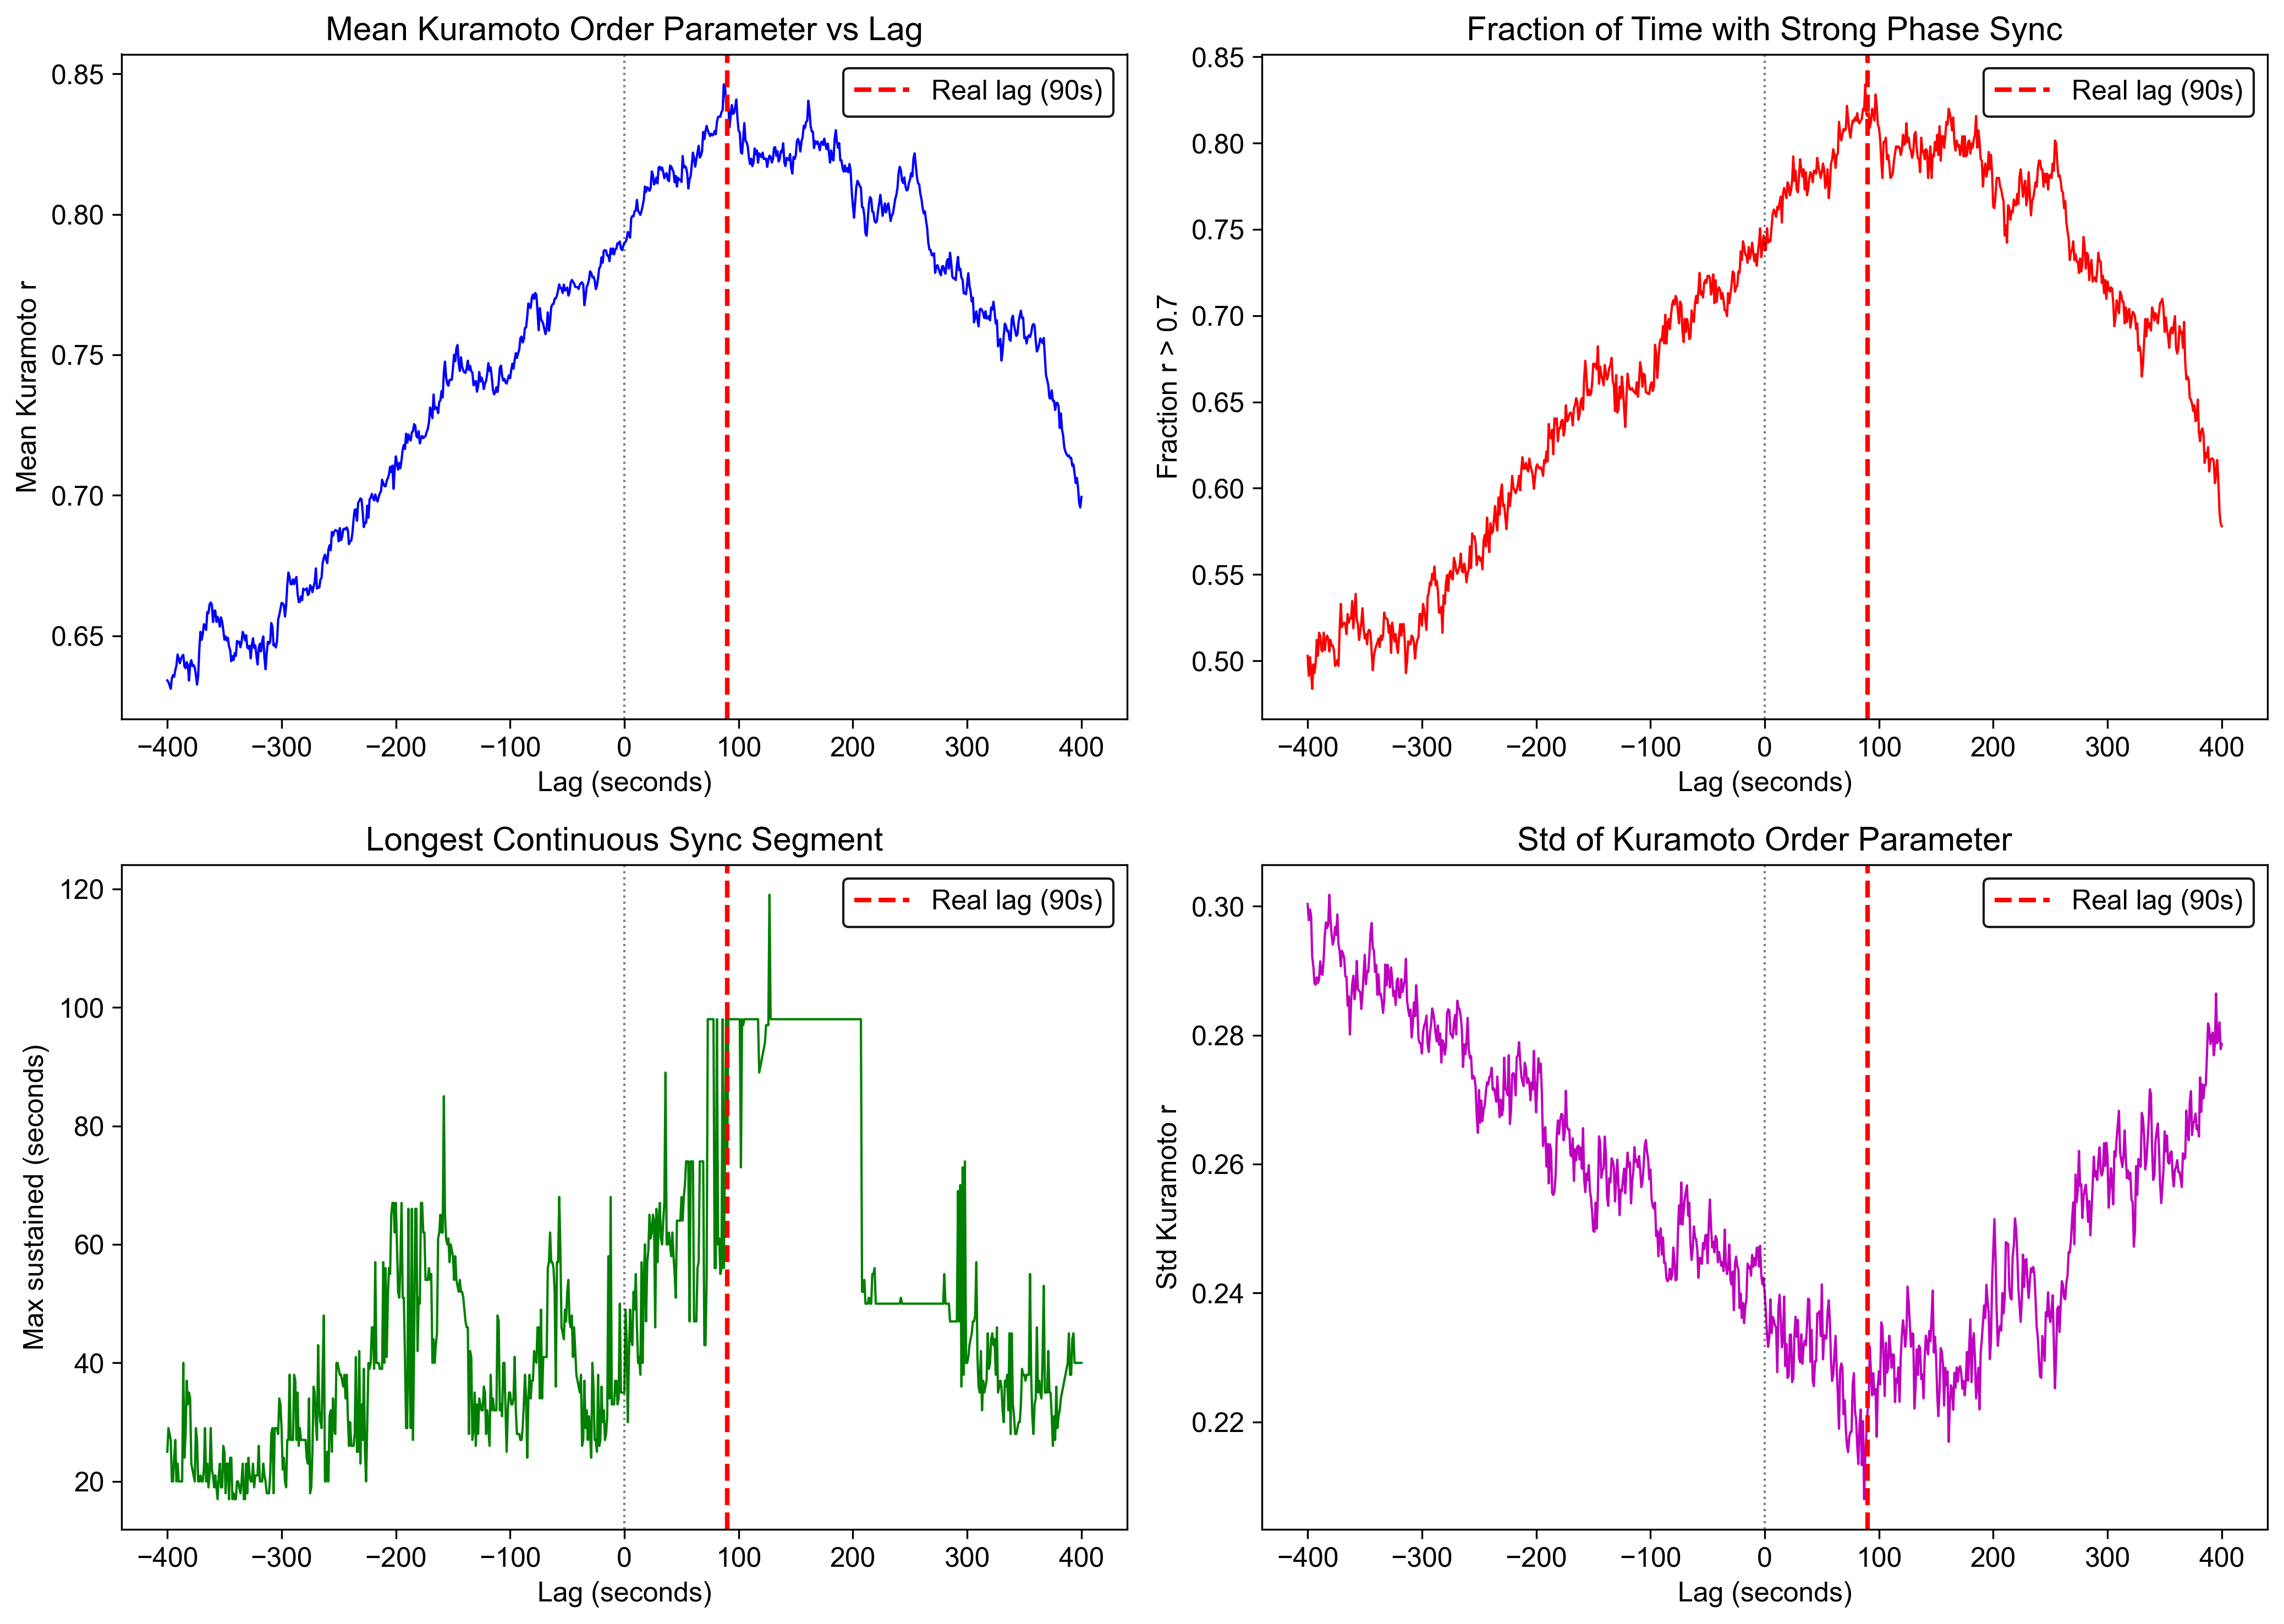

In [8]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

# Real lag for marking
real_lag = int(18600 / df_hour['FormacionVelocidad'].mean())

axes[0, 0].plot(results_df['lag'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(results_df['lag'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(results_df['lag'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(results_df['lag'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

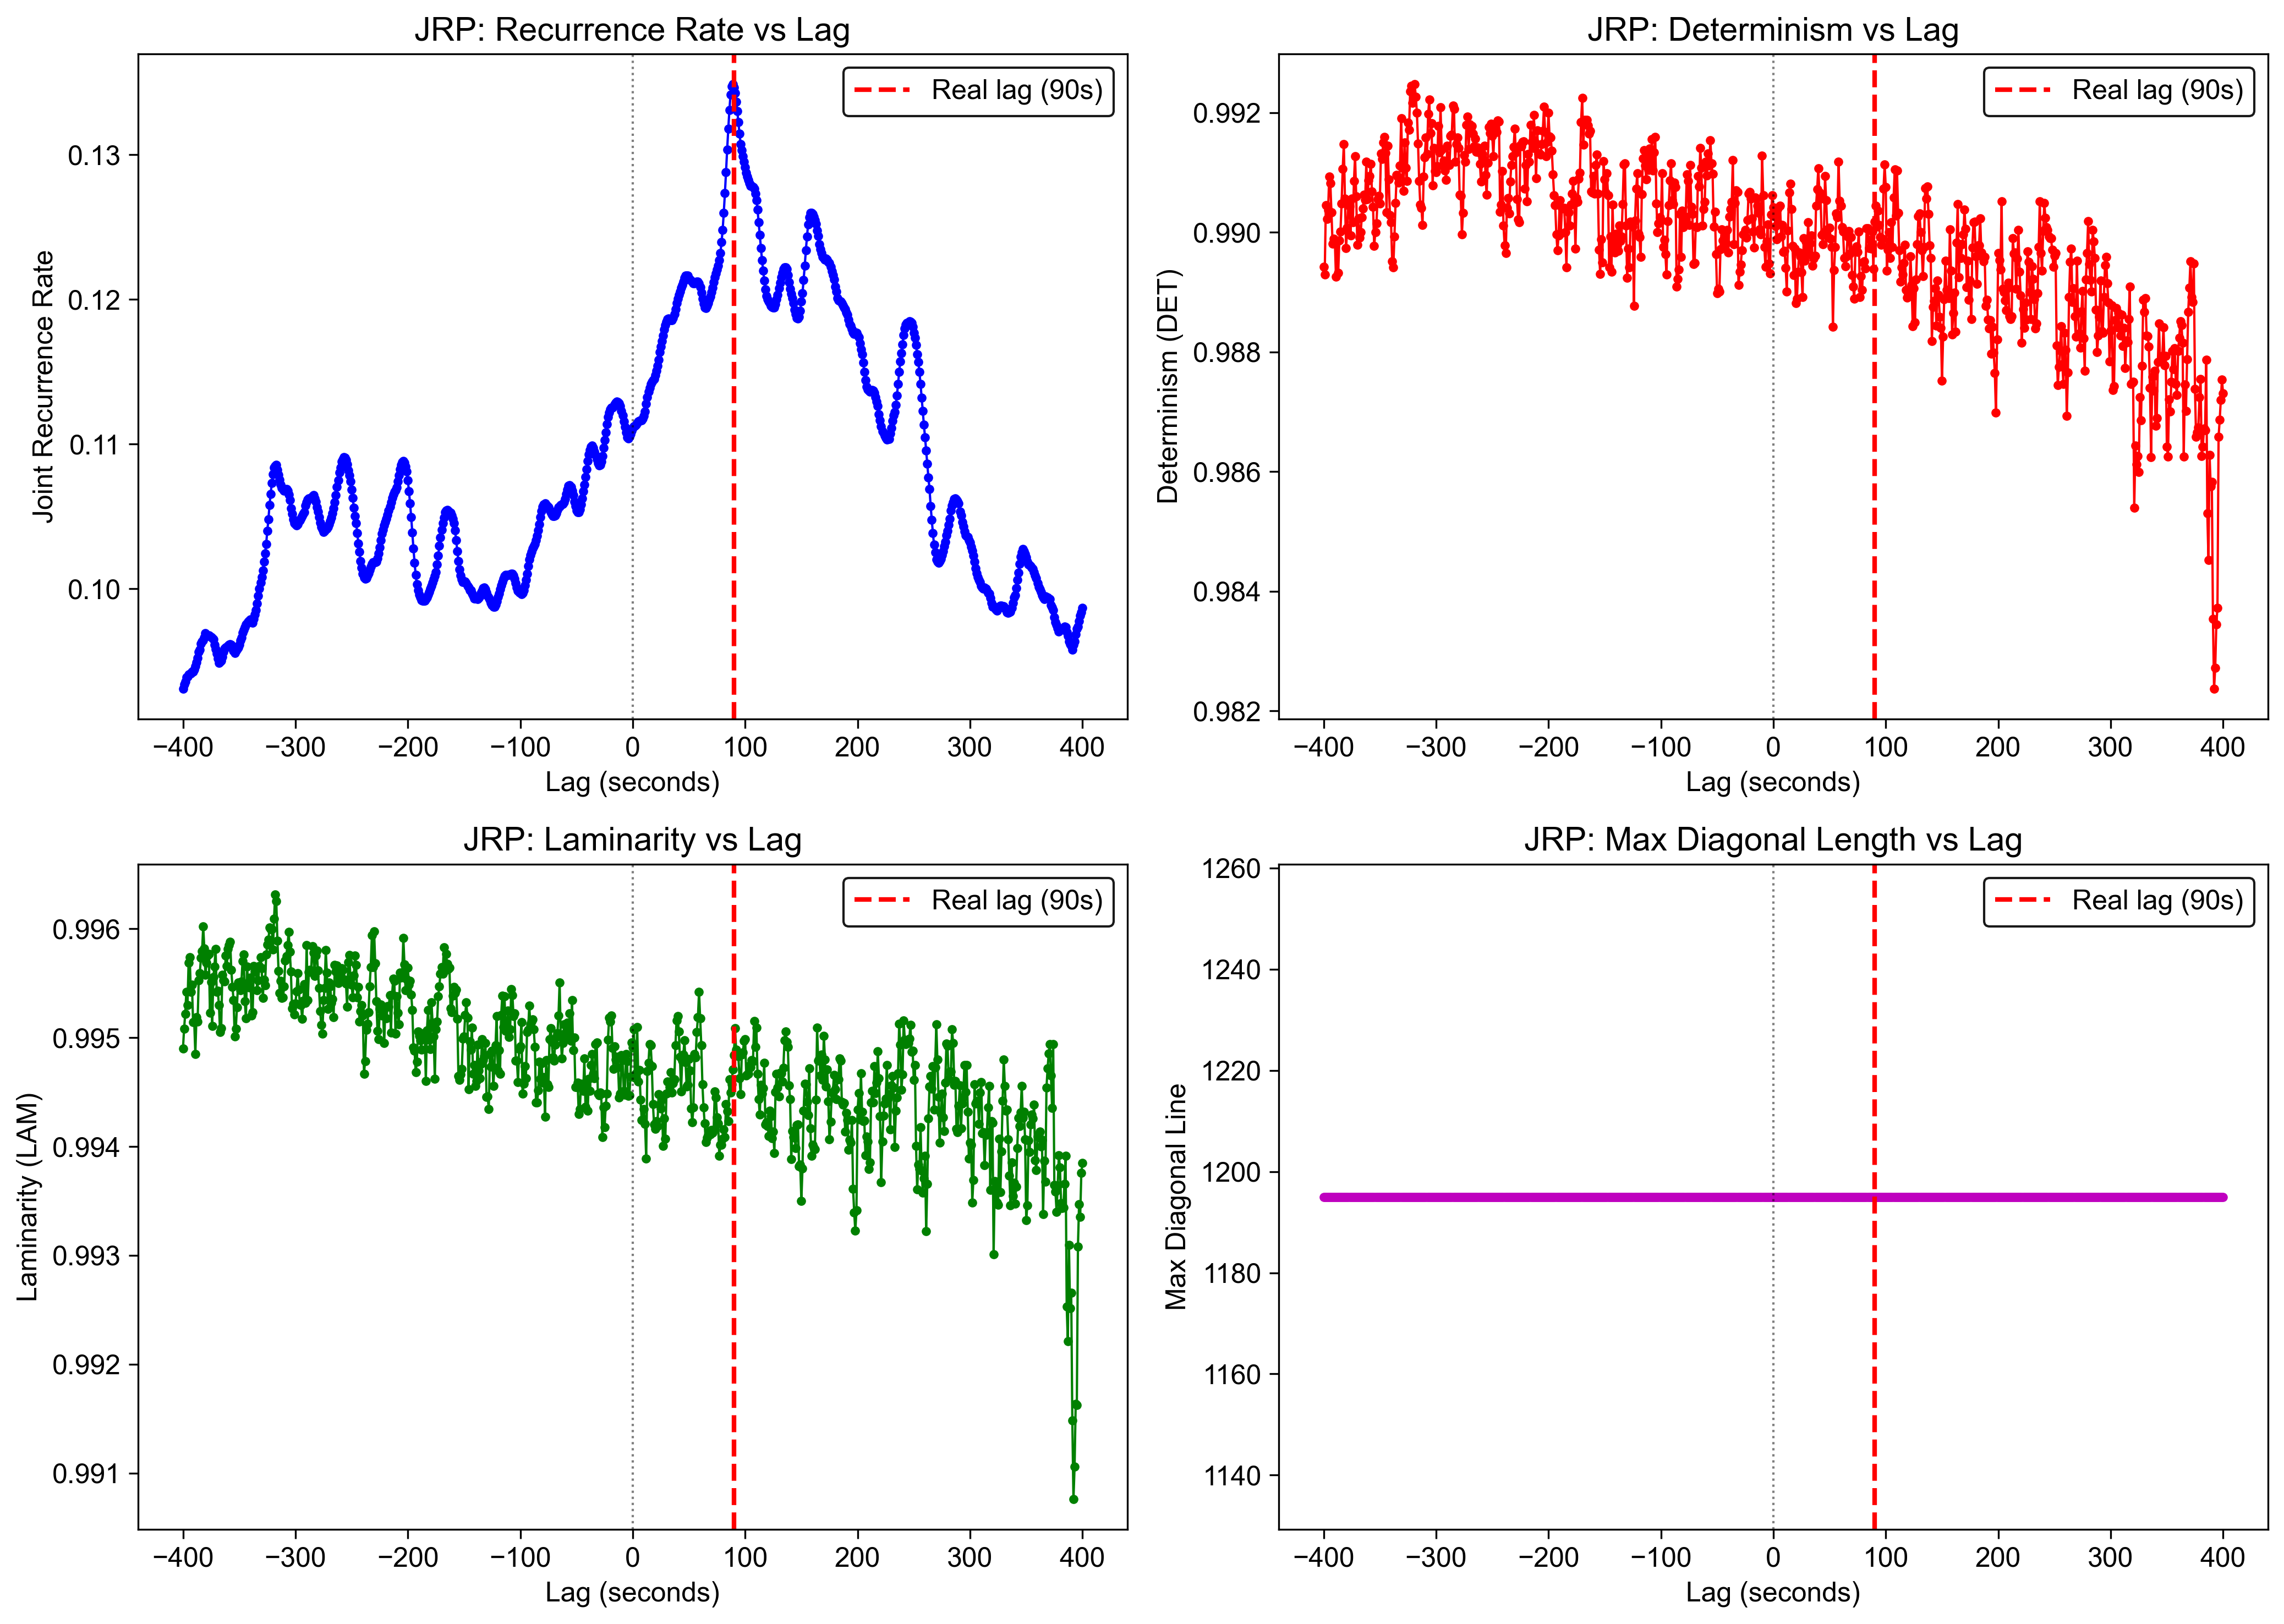

In [9]:
# Plot JRP metrics (only computed every 10s)
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

# Real lag for marking
real_lag = int(18600 / df_hour['FormacionVelocidad'].mean())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(jrp_df['lag'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(jrp_df['lag'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(jrp_df['lag'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=real_lag, color='red', linestyle='--', linewidth=2, label=f'Real lag ({real_lag}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

In [10]:
# Combined analysis: Find optimal lag from both methods
# KURAMOTO: Use 'Fraction of time with strong phase sync' (frac_above_07) AND 'Max Mean r' (r_mean) as criteria
# JRP: Use Determinism (DET), Laminarity (LAM), Recurrence Rate (RR) as primary criteria
# Discard extreme lags (±max_lag) from JRP analysis
def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v > min_v:
        return (series - min_v) / (max_v - min_v)
    return series * 0

# Kuramoto score = frac_above_07 * r_mean (combining two criteria)
results_df['kuramoto_score'] = normalize(results_df['frac_above_07']) * normalize(results_df['r_mean'])

# JRP score = normalized product of DET, LAM, RR (excluding extreme lags)
jrp_valid = results_df[(results_df['lag'] != -max_lag) & (results_df['lag'] != max_lag) & (results_df['jrp_RR'] > 0)].copy()
results_df['jrp_score'] = 0.0
if len(jrp_valid) > 0:
    jrp_score_vals = (
        normalize(jrp_valid['jrp_DET']) * normalize(jrp_valid['jrp_LAM']) * normalize(jrp_valid['jrp_RR'])
    )
    results_df.loc[jrp_valid.index, 'jrp_score'] = jrp_score_vals
    jrp_valid['jrp_score'] = jrp_score_vals  # Also add to jrp_valid for nlargest
results_df['combined_score'] = (results_df['kuramoto_score'] + results_df['jrp_score']) / 2

print('=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

print('\n=== Top 10 by JRP Score (DET × LAM × RR, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag', 'jrp_RR', 'jrp_DET', 'jrp_LAM', 'jrp_max_diag', 'jrp_score']].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===
 lag   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
  88 0.846137       0.834028                 74        0.999562
  87 0.846231       0.819016                 56        0.957143
  97 0.838337       0.828190                 98        0.947249
  98 0.840841       0.821518                 98        0.940126
 161 0.840396       0.819850                 98        0.933497
  94 0.838871       0.819850                 98        0.926694
  91 0.839233       0.817348                 98        0.921400
  89 0.839718       0.816514                 98        0.921240
  86 0.837050       0.819850                 98        0.918574
 162 0.836949       0.817348                 98        0.911289

=== Top 10 by JRP Score (DET × LAM × RR, excl. extreme lags) ===
 lag   jrp_RR  jrp_DET  jrp_LAM  jrp_max_diag  jrp_score
  91 0.134264 0.990445 0.995087          1195   0.613156
  99 0.129497 0.991132 0.994971          1195   0.571906
 

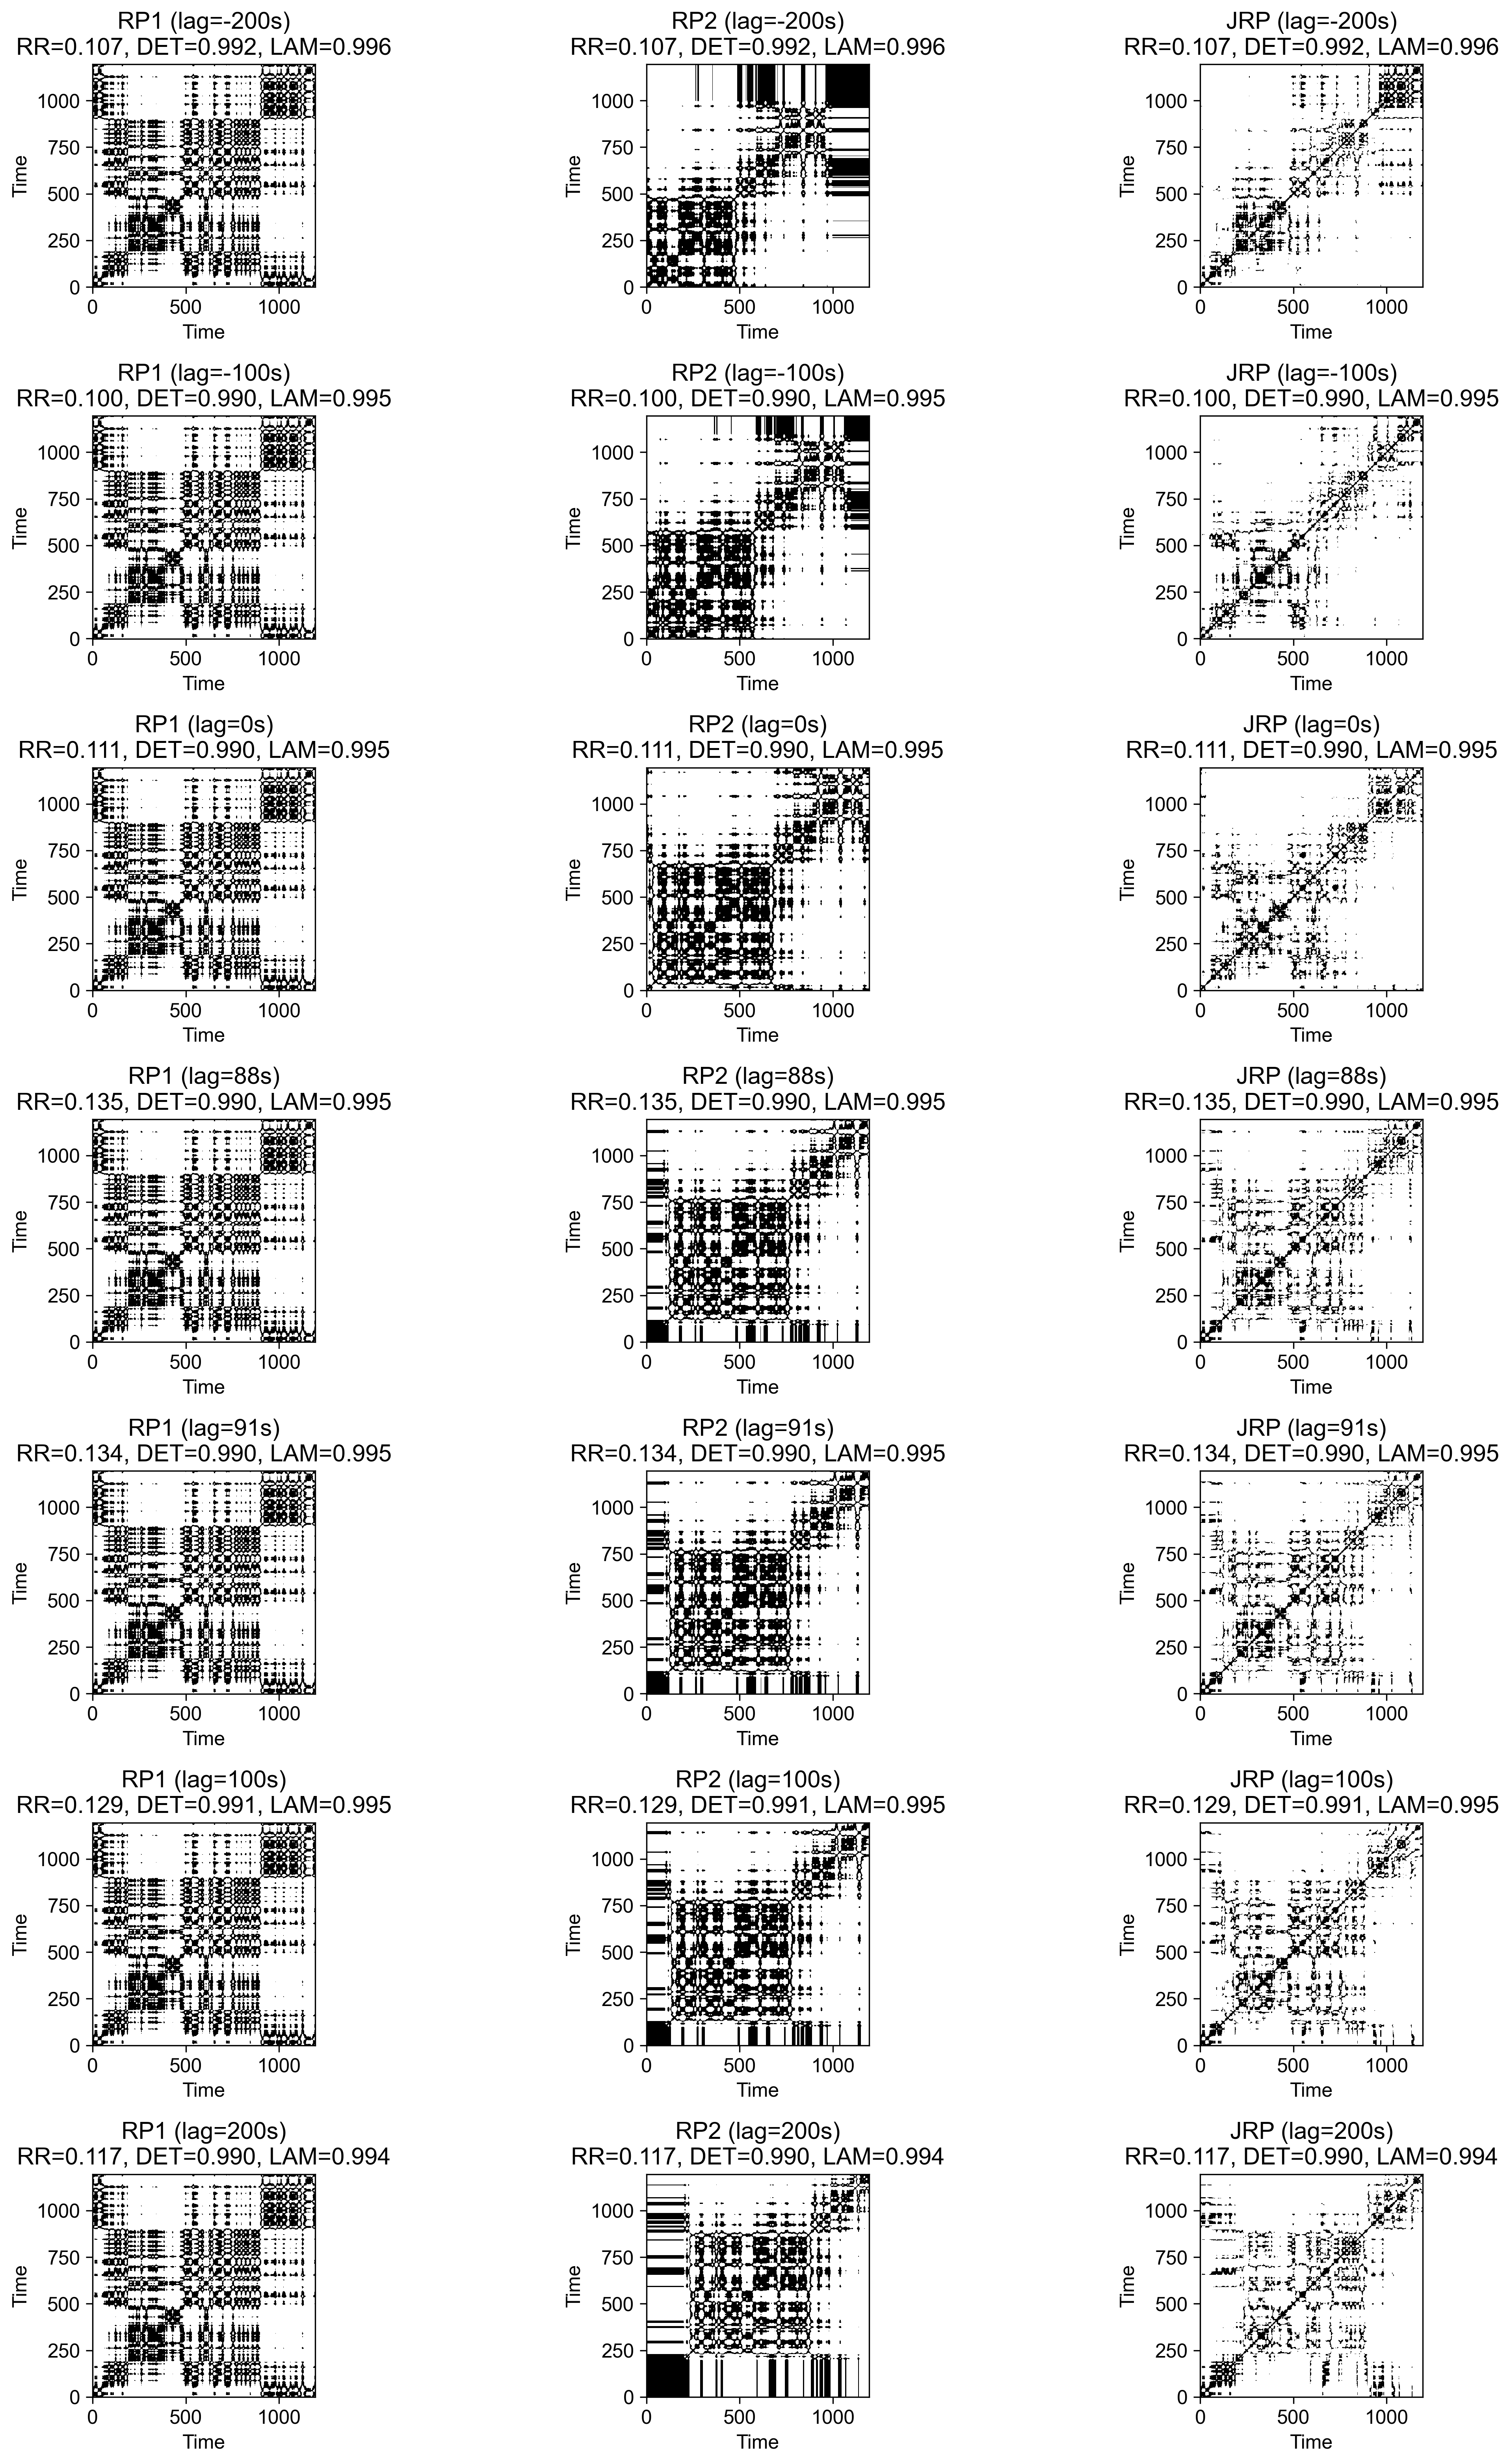

In [11]:
# Detailed JRP visualization at key lags
# Include best Kuramoto lag (frac_above_07 × r_mean) and best JRP lag
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_jrp_lag = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 0

key_lags = [-200, -100, 0, 100, 200, best_kuramoto_lag, best_jrp_lag]
key_lags = sorted(set([l for l in key_lags if -max_lag <= l <= max_lag]))

fig, axes = plt.subplots(len(key_lags), 3, figsize=(15, 3*len(key_lags)))
fig.patch.set_facecolor('white')
if len(key_lags) == 1:
    axes = axes.reshape(1, -1)

for idx, lag in enumerate(key_lags):
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_smooth[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_smooth[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_smooth.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_smooth, m=m_opt, tau=tau_opt)
    s2_emb = embed_time_series(s2_shifted, m=m_opt, tau=tau_opt)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=rate_opt)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=rate_opt)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        for ax, rp, title in zip(axes[idx], [rp1, rp2, jrp], 
                                  [f'RP1 (lag={lag}s)', f'RP2 (lag={lag}s)', f'JRP (lag={lag}s)']):
            im = ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
            ax.set_title(f'{title}\nRR={metrics["RR"]:.3f}, DET={metrics["DET"]:.3f}, LAM={metrics["LAM"]:.3f}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Time')
    else:
        for ax in axes[idx]:
            ax.text(0.5, 0.5, 'Too short', ha='center', va='center')

plt.tight_layout()
plt.show()

In [12]:
# JRP at best Kuramoto lag
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])

for lag in [best_kuramoto_lag]:
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_smooth[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_smooth[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_smooth.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_smooth, m=m_opt, tau=tau_opt)
    s2_emb = embed_time_series(s2_shifted, m=m_opt, tau=tau_opt)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=rate_opt)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=rate_opt)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        print(f'\n=== Lag = {lag}s ===')
        print(f'  JRP: RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
        print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')


=== Lag = 88s ===
  JRP: RR=0.1347, DET=0.9900, LAM=0.9946
  max_diag=1195, mean_diag=8.6, max_vert=89


In [13]:
# Save results
results_df.to_parquet('../data/kuramoto_jrp_lag_sweep_T11_T12.parquet')
print('Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_T11_T12.parquet')

# Summary
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec'])
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print(f'\n=== FINAL SUMMARY ===')
print(f'Real lag (distance/speed):                          {real_lag}s ({real_lag/60:.1f} min)')
print(f'Best lag (Kuramoto - frac_above_07 × r_mean):     {best_kuramoto}s ({best_kuramoto/60:.1f} min)  [max_sustained={best_kuramoto_sustained}s, frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.3f}]')
print(f'Best lag (JRP - DET/LAM/RR, excl. extreme lags):  {best_jrp}s ({best_jrp/60 if best_jrp != "N/A" else "N/A"}:.1f min)')
print(f'Best lag (Combined):                               {best_combined}s ({best_combined/60:.1f} min)')

error_kuramoto = abs(best_kuramoto - real_lag)
error_jrp = abs(best_jrp - real_lag) if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - real_lag)
print(f'\nErrors vs real lag:')
print(f'  Kuramoto:  {error_kuramoto}s')
print(f'  JRP:       {error_jrp}s' if error_jrp != 'N/A' else '  JRP:       N/A')
print(f'  Combined:  {error_combined}s')

Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_T11_T12.parquet

=== FINAL SUMMARY ===
Real lag (distance/speed):                          90s (1.5 min)
Best lag (Kuramoto - frac_above_07 × r_mean):     88s (1.5 min)  [max_sustained=74s, frac_above_07=0.834, r_mean=0.846]
Best lag (JRP - DET/LAM/RR, excl. extreme lags):  91s (1.5166666666666666:.1f min)
Best lag (Combined):                               91s (1.5 min)

Errors vs real lag:
  Kuramoto:  2s
  JRP:       1s
  Combined:  1s
